In [30]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
import operator
import random

In [31]:
class State(TypedDict):
    # operator.add ensures nodes append to the list rather than overwrite it
    roster: Annotated[list[str], operator.add]
    search_attempts: int

In [32]:
def recruit_knight_tool() -> str:
    knights = ["Ser Robyn", "Ser Lyonel", "Ser Raymun", "Ser Humfrey", "Ser Steffon", "Ser Valarr"]
    return random.choice(knights)

# 3. Parallel Nodes (Fanning Out)
def search_tourney_grounds(state: State):
    print("Searching the tourney grounds...")
    new_knight = recruit_knight_tool()
    # We return a list with ONE item. The reducer (operator.add) will append it to the main state.
    return {"roster": [new_knight]}

def search_flea_bottom(state: State):
    print("Searching Flea Bottom...")
    new_knight = recruit_knight_tool()
    return {"roster": [new_knight]}

# 4. Evaluation Node (Fanning In)
# LangGraph automatically waits for parallel branches to finish before running this
def evaluate_roster(state: State):
    # Increment attempts to prevent infinite loops (good practice)
    current_attempts = state.get("search_attempts", 0) + 1
    current_count = len(state.get("roster", []))
    print(f"--- Evaluation: {current_count} knights found after {current_attempts} attempts ---")
    return {"search_attempts": current_attempts}

# 5. Conditional Routing Logic
def check_roster_size(state: State):
    # Dunk + 6 others = 7
    if len(state.get("roster", [])) < 6 and state.get("search_attempts", 0) < 5:
        return ["search_tourney_grounds", "search_flea_bottom"]
    return END

In [33]:
graph = StateGraph(State)

graph.add_node("search_tourney_grounds", search_tourney_grounds)
graph.add_node("search_flea_bottom", search_flea_bottom)
graph.add_node("evaluate_roster", evaluate_roster)

# FAN-OUT: Start goes to both search nodes simultaneously
graph.add_edge(START, "search_tourney_grounds")
graph.add_edge(START, "search_flea_bottom")

# FAN-IN: Both search nodes point to the evaluator. 
graph.add_edge("search_tourney_grounds", "evaluate_roster")
graph.add_edge("search_flea_bottom", "evaluate_roster")

# CONDITIONAL LOOP: If we need more knights, fan out again. Otherwise, end.
graph.add_conditional_edges(
    "evaluate_roster", 
    check_roster_size
)

model = graph.compile()

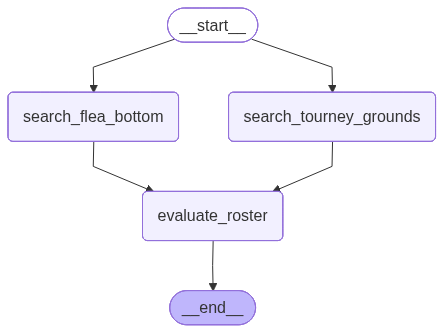

In [35]:
Image(model.get_graph().draw_mermaid_png())

In [36]:
initial_state = {"roster": ["Ser Duncan the Tall"], "search_attempts": 0}
final_state = model.invoke(initial_state)

print("\nFinal Roster:", final_state["roster"])

Searching Flea Bottom...
Searching the tourney grounds...
--- Evaluation: 3 knights found after 1 attempts ---
Searching Flea Bottom...
Searching the tourney grounds...
--- Evaluation: 5 knights found after 2 attempts ---
Searching the tourney grounds...
Searching Flea Bottom...
--- Evaluation: 7 knights found after 3 attempts ---

Final Roster: ['Ser Duncan the Tall', 'Ser Lyonel', 'Ser Valarr', 'Ser Valarr', 'Ser Lyonel', 'Ser Robyn', 'Ser Valarr']
